<div style=" background-color:#0A2B07;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 5 DATA SCIENTIST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Segmentez des clients d'un site e-commerce
</h2>
</div>

## **INITIALISATION**

In [251]:
# ============================================================
# LIBRAIRIES DE BASE
# ============================================================

# Manipulation de données
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement et clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [191]:
# Définir le dossier où sont stockés les fichiers CSV
data_path = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# Charger tous les fichiers CSV en utilisant le chemin centralisé
customers = pd.read_csv(f"{data_path}\\olist_customers_dataset.csv")
geolocation = pd.read_csv(f"{data_path}\\olist_geolocation_dataset.csv")
order_items = pd.read_csv(f"{data_path}\\olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{data_path}\\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{data_path}\\olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{data_path}\\olist_orders_dataset.csv")
products = pd.read_csv(f"{data_path}\\olist_products_dataset.csv")
sellers = pd.read_csv(f"{data_path}\\olist_sellers_dataset.csv")


In [123]:
def profile_dataframe(df, table_name, primary_keys=None, verbose=True):
    """
    Profiling complet d'un DataFrame avec informations sur les colonnes
    et éventuellement sur la clé primaire, avec quartiles pour les colonnes numériques et dates.

    Arguments :
        df : DataFrame à analyser
        table_name : nom logique de la table (string)
        primary_keys : dictionnaire {nom_table: [liste_colonnes_identifiants]}
        verbose : bool, si True affiche les infos générales
    
    Retour :
        DataFrame contenant pour chaque colonne :
        - première valeur
        - type pandas
        - type détaillé (numérique, texte, date, booléen)
        - nombre de valeurs uniques
        - % doublons si clé primaire
        - % valeurs manquantes
        - % zéros (numérique)
        - min, max, médiane
        - 1er quartile (25%), 3ème quartile (75%)
        - moyenne (numérique)
    """
    n_rows, n_cols = df.shape

    # Gestion clé primaire
    pk_cols = []
    n_duplicates = None
    if primary_keys and table_name in primary_keys:
        pk_cols = [c for c in primary_keys[table_name] if c in df.columns]
        if pk_cols:
            n_duplicates = df.duplicated(subset=pk_cols, keep=False).sum()
    
    if verbose:
        print(f"\n=== Table : {table_name} ===")
        print(f"Taille : {n_rows} lignes × {n_cols} colonnes")
        if pk_cols:
            pk_str = "', '".join(pk_cols)
            print(f"Clé primaire : '{pk_str}' → {n_duplicates} doublons")
        else:
            if primary_keys and table_name in primary_keys:
                print("Clé primaire définie dans primary_keys mais colonnes manquantes dans le DataFrame")
            else:
                print("Clé primaire : non renseignée")
    
    results = []
    
    for col in df.columns:
        serie = df[col]
        first_value = serie.iloc[0]
        dtype = serie.dtype

        # type détaillé
        if pd.api.types.is_numeric_dtype(serie):
            detailed_type = "numérique"
        elif pd.api.types.is_bool_dtype(serie):
            detailed_type = "booléen"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            detailed_type = "date"
        else:
            detailed_type = "texte"
        
        n_unique = serie.nunique(dropna=False)
        pct_missing = round(serie.isna().mean() * 100, 2)
        
        if detailed_type == "numérique":
            pct_zeros = round((serie == 0).mean() * 100, 2)
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = round(serie.mean(), 2)
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        elif detailed_type == "date":
            pct_zeros = np.nan
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = np.nan
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        else:
            pct_zeros = np.nan
            col_min = np.nan
            col_max = np.nan
            median = np.nan
            mean = np.nan
            q25 = np.nan
            q75 = np.nan

        pct_duplicates = np.nan
        if col in pk_cols:
            pct_duplicates = round((1 - serie.nunique(dropna=False) / n_rows) * 100, 2)
        
        results.append({
            "column": col,
            "first_value": first_value,
            "dtype": dtype,
            "detailed_type": detailed_type,
            "n_unique": n_unique,
            "pct_duplicates": pct_duplicates,
            "pct_missing": pct_missing,
            "pct_zeros": pct_zeros,
            "min": col_min,
            "q25": q25,
            "median": median,
            "q75": q75,
            "max": col_max,
            "mean": mean
        })

    if verbose:
        print("\n--- Tableau de profil ---")
    
    return pd.DataFrame(results)


In [124]:
def plot_distributions(df, columns, table_name="Table", save_path=None, show_values=False, color_dict=None):
    """
    Affiche la distribution d'une ou plusieurs colonnes d'un DataFrame.

    Arguments :
        df : DataFrame pandas
        columns : liste de colonnes ou une seule colonne (string)
        table_name : nom de la table, affiché dans le titre
        save_path : chemin pour sauvegarder la figure (optionnel, PNG, fond transparent)
        show_values : bool, si True affiche les valeurs au-dessus des barres / boxplots
        color_dict : dict, mapping valeur -> couleur pour barplots catégoriels
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col not in df.columns:
            print(f"Colonne '{col}' non trouvée dans le DataFrame.")
            continue

        serie = df[col]
        plt.figure(figsize=(14, 5))

        # Déterminer le type
        if pd.api.types.is_numeric_dtype(serie):
            type_col = "numérique"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            type_col = "date"
        else:
            type_col = "catégoriel"

        # Échapper les underscores pour LaTeX dans le titre
        col_tex = col.replace("_", r"\_")
        table_tex = table_name.replace("_", r"\_")
        title_str = fr"Distribution de la variable $\mathbf{{\mathit{{{col_tex}}}}}$ de la table $\mathbf{{\mathit{{{table_tex}}}}}$ ({type_col})"

        if type_col in ["numérique", "date"]:
            # histogramme + boxplot
            plt.subplot(1, 2, 1)
            if pd.api.types.is_integer_dtype(serie) and serie.nunique() <= 20:
                bins = range(int(serie.min()), int(serie.max()) + 2)
                sns.histplot(serie, bins=bins, kde=False, color="forestgreen")
                plt.xticks(range(int(serie.min()), int(serie.max()) + 1))
            else:
                sns.histplot(serie, bins=30, kde=True, color="forestgreen")
            plt.ylabel("Fréquence")
            plt.xlabel("")
            plt.title(title_str, fontsize=12)

            plt.subplot(1, 2, 2)
            ax = sns.boxplot(x=serie, color="forestgreen")
            plt.xlabel("")
            plt.title("Boxplot", fontsize=12)

            if show_values:
                median = serie.median()
                plt.text(median, 0.5, f"median={median:.2f}", horizontalalignment='center', 
                         verticalalignment='bottom', color='black', fontsize=10)

        else:
            # barplot pour valeurs catégorielles
            counts = serie.value_counts()
            if color_dict:
                colors = [color_dict.get(v, "forestgreen") for v in counts.index]  # vert forêt par défaut
            else:
                colors = ["forestgreen"] * len(counts)
            ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
            plt.ylabel("Fréquence")
            plt.xlabel("")
            plt.xticks(rotation=45)
            plt.title(title_str, fontsize=12)

            if show_values:
                for i, v in enumerate(counts.values):
                    ax.text(i, v + max(counts.values)*0.01, str(v), ha='center', fontsize=9)

        plt.tight_layout(rect=[0, 0, 1, 0.9])

        if save_path:
            plt.savefig(save_path, transparent=True)
        plt.show()


# color_segment = {
#     "loyaux": "#2851FF",
#     "loyalistes potentiels": "#092AAE",
#     "Champions": "#15C574",
#     "a réactiver": "#1D8C56",
#     "perdus": "#910909",
#     "a risque": "#E72C26"
# }
# plot_distributions(rfm_v2, ["segment"], table_name="rfm_v2", show_values=True, color_dict=color_segment)


In [125]:
def value_frequencies(df, column):
    """
    Affiche un tableau avec la fréquence des valeurs uniques d'une colonne.
    """
    if column not in df.columns:
        print(f"Colonne '{column}' non trouvée dans le DataFrame.")
        return
    
    freqs = df[column].value_counts(dropna=False)
    freq_table = pd.DataFrame({
        "valeur": freqs.index,
        "fréquence": freqs.values,
        "pourcentage": (freqs.values / len(df) * 100).round(2)
    })
    return freq_table


# **TODO**

| Étape | Objectif | Actions concrètes | Référentiel CE associé | Avancement |
|-------|----------|-----------------|----------------------|-----------|
| 1. Sélection des features | Choisir les variables pertinentes pour le clustering | - Vérifier la qualité et la variance des variables<br>- Retirer les colonnes redondantes ou peu discriminantes<br>- S’assurer que les variables catégorielles sont encodées et les variables continues normalisées | CE1, CE2, CE3, CE4 | ✅ Terminé |
| 2. Prétraitement | Préparer le dataset pour l’algorithme | - Remplacer les NaN si nécessaire ou filtrer<br>- Appliquer StandardScaler ou MinMaxScaler sur les variables continues<br>- Vérifier les variables binaires et one-hot | CE1, CE3, CE4 | ✅ Terminé (df_cluster prêt) |
| 3. Clustering initial | Se familiariser avec l’algorithme | - Lancer un k-means avec 3 à 6 clusters<br>- Observer les résultats initiaux | CE5, CE6, CE8 | ⬜ Pas encore fait |
| 4. Choix du nombre optimal de clusters | Déterminer le nombre de clusters pertinent | - Méthode data-driven : silhouette, elbow, gap statistic<br>- Méthode métier : cohérence avec le business et la lisibilité | CE6, CE1 | ⬜ Pas encore fait |
| 5. Évaluation du clustering | Mesurer la qualité du modèle | - Calculer silhouette score et inertia<br>- Vérifier la stabilité à plusieurs initialisations (random_state)<br>- Analyser la répartition des clusters | CE1, CE2, CE3, CE4, CE5 | ⬜ Pas encore fait |
| 6. Interprétation des clusters | Caractériser les clusters en lien avec les features | - Calculer les moyennes, médianes et distributions par cluster<br>- Identifier les comportements typiques pour chaque cluster | CE5, CE6 | ⬜ Pas encore fait |
| 7. Comparaison d’algorithmes | Tester différentes méthodes | - KMeans vs Agglomerative / DBSCAN (si pertinent)<br>- Comparer scores et stabilité | CE9, CE2, CE4, CE5 | ⬜ Pas encore fait |
| 8. Validation métier | S’assurer que le clustering est compréhensible et exploitable | - Vérifier la tangibilité des clusters pour le business<br>- Ajuster le nombre de clusters ou les features si nécessaire | CE5, CE6 | ⬜ Pas encore fait |
| 9. Stratégie nouveaux clients | Définir comment assigner de nouveaux clients | - Standardiser les nouvelles données avec les mêmes transformations<br>- Affecter le cluster le plus proche (distance euclidienne ou centroid) | CE7, CE8 | ⬜ Pas encore fait |
| 10. Documentation et maintenance | Assurer la traçabilité et reproductibilité | - Commenter le code<br>- Respecter PEP8<br>- Documenter les choix d’algorithme, hyper-paramètres et features | CE7, CE9 | ⬜ Pas encore fait |

# **CADRAGE**

**Objectif métier de la segmentation**
- Identifier des groupes de clients homogènes pour adapter les actions marketing

**Usage marketing attendu**
- Campagnes ciblées, offres personnalisées, priorisation des clients, relances, fidélisation

**Contraintes**
- Interprétabilité : les segments doivent pouvoir être expliqués aux équipes marketing
- Stabilité : segmentation stable dans le temps pour comparer les clusters
- Recalcul : prévoir la fréquence et la méthode pour mettre à jour la segmentation


# **ANALYSE EXPLORATOIRE ET NETTOYAGE DES DONNÉES**

In [176]:
print('customer', customers.columns.tolist())
print('geolocation', geolocation.columns.tolist())
print('order_items', order_items.columns.tolist())
print('order_payments', order_payments.columns.tolist())
print('order_reviews', order_reviews.columns.tolist())
print('orders', orders.columns.tolist())
print('products', products.columns.tolist())
print('sellers', sellers.columns.tolist())

customer ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
geolocation ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
order_items ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
order_payments ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
order_reviews ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
orders ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
products ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', '

In [177]:
primary_keys = {
    "customers": ["customer_unique_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_city"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"]
}

## **CUSTOMER**


=== Table : customers ===
Taille : 99441 lignes × 5 colonnes
Clé primaire : 'customer_unique_id' → 6342 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_id,06b8999e2fba1a1fbc88172c00ba8bc7,object,texte,99441,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,customer_unique_id,861eff4711a542e4b93843c6dd7febb0,object,texte,96096,3.36,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,customer_zip_code_prefix,14409,int64,numérique,14994,NaN,0.0,0.0,1003.0,11347.0,24416.0,58900.0,99990.0,35137.47
3,customer_city,franca,object,texte,4119,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,customer_state,SP,object,texte,27,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\barre\AppData\Local\Temp\ipykernel_20520\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


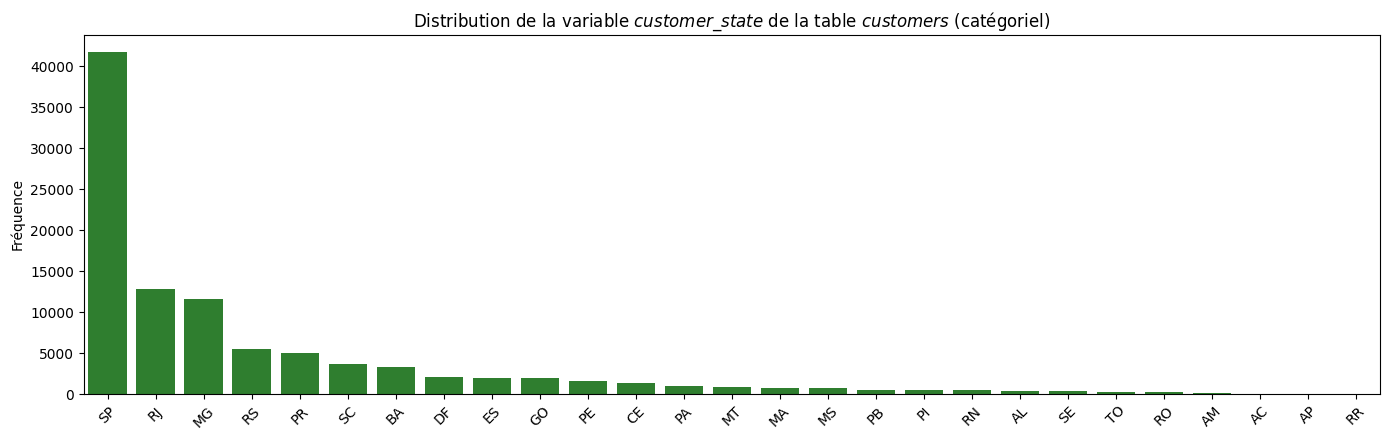

In [181]:
# Suppression des doublons sur customer_unique_id
# customers = customers.drop_duplicates(subset=['customer_unique_id'], keep='first')

# Affichage du profil
profile_customers = profile_dataframe(customers, "customers", primary_keys)
display(profile_customers)

# Affichage de la distribution
plot_distributions(customers, "customer_state", table_name="customers")

## **GEOLOCALISATION**


=== Table : geolocation ===
Taille : 27907 lignes × 5 colonnes
Clé primaire : 'geolocation_zip_code_prefix', 'geolocation_city' → 0 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,geolocation_zip_code_prefix,1037,int64,numérique,19015,31.86,0.0,0.0,1001.000000,8381.000000,35868.000000,70382.000000,99990.000000,40390.17
1,geolocation_lat,-23.545621,float64,numérique,27501,NaN,0.0,0.0,-36.605374,-23.577172,-22.735080,-15.837920,45.065933,-19.41
2,geolocation_lng,-46.639292,float64,numérique,27504,NaN,0.0,0.0,-98.484121,-48.688732,-46.649752,-43.636016,121.105394,-46.26
3,geolocation_city,sao paulo,object,texte,8011,71.29,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,geolocation_state,SP,object,texte,27,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\barre\AppData\Local\Temp\ipykernel_20520\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


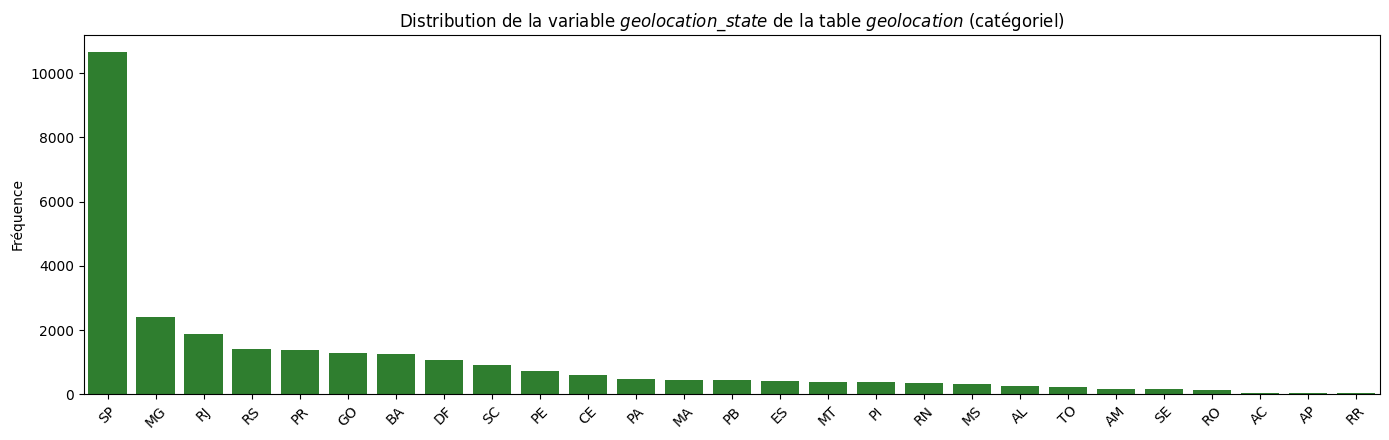

In [182]:
# Suppression des doublons
geolocation = geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geolocation_city'], keep='first')

# Affichage du profil
profile_geolocation = profile_dataframe(geolocation, "geolocation", primary_keys)
display(profile_geolocation)
# Affichage de la distribution
plot_distributions(geolocation, "geolocation_state", table_name="geolocation")

## **ORDER_ITEMS**


=== Table : order_items ===
Taille : 112650 lignes × 7 colonnes
Clé primaire : 'order_id', 'order_item_id' → 0 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,order_id,00010242fe8c5a6d1ba2dd792cb16214,object,texte,98666,12.41,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,order_item_id,1,int64,numérique,21,99.98,0.0,0.00,1,1.0,1.0,1.0,21,1.20
2,product_id,4244733e06e7ecb4970a6e2683c13e61,object,texte,32951,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,seller_id,48436dade18ac8b2bce089ec2a041202,object,texte,3095,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,shipping_limit_date,2017-09-19 09:45:35,datetime64[ns],date,93318,NaN,0.0,NaN,2016-09-19 00:15:34,2017-09-20 20:57:27.500000,2018-01-26 13:59:35,2018-05-10 14:34:00.750000128,2020-04-09 22:35:08,NaN
5,price,58.9,float64,numérique,5968,NaN,0.0,0.00,0.85,39.9,74.99,134.9,6735.0,120.65
6,freight_value,13.29,float64,numérique,6999,NaN,0.0,0.34,0.0,13.08,16.26,21.15,409.68,19.99


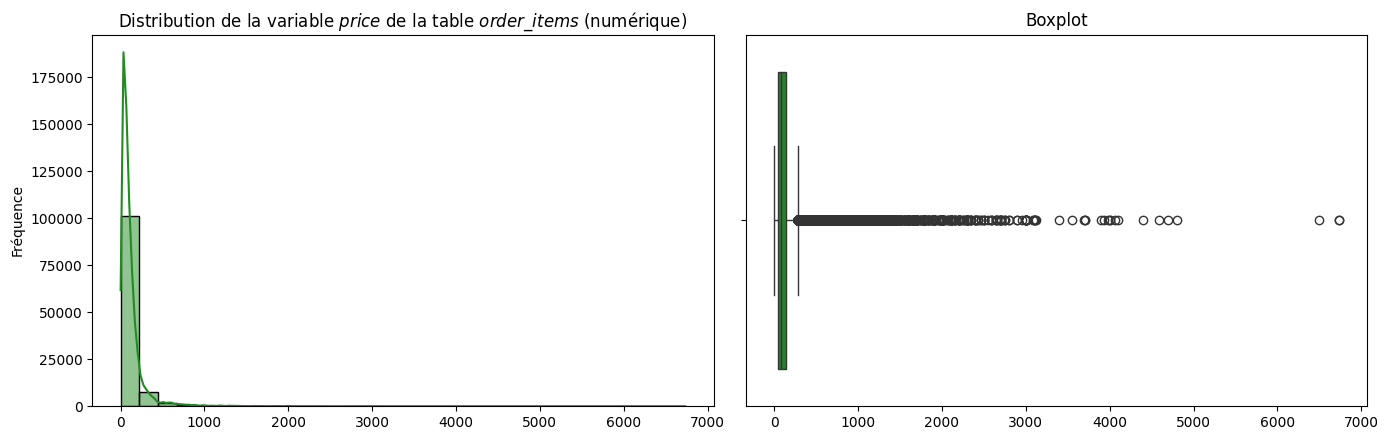

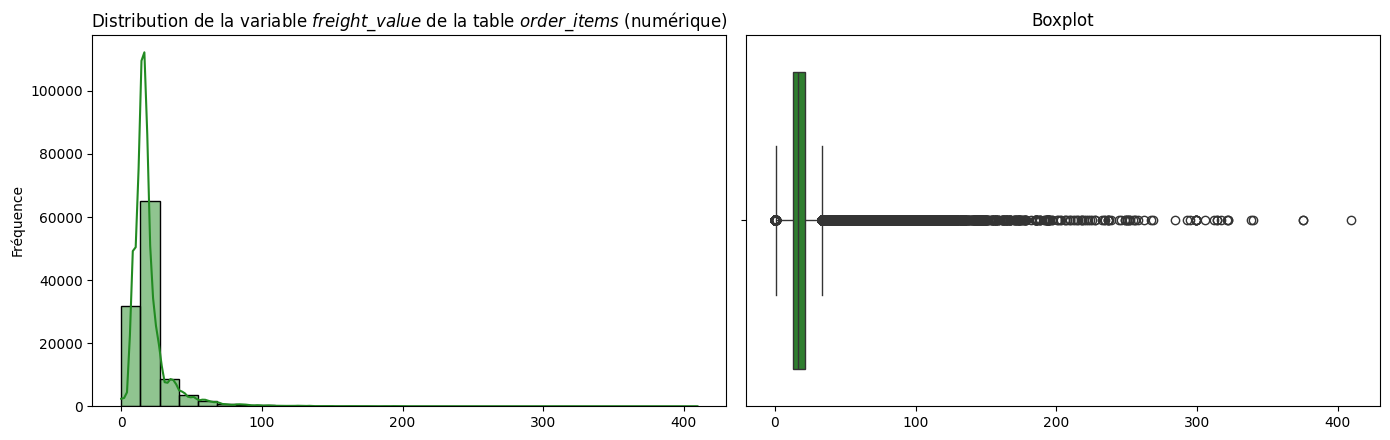

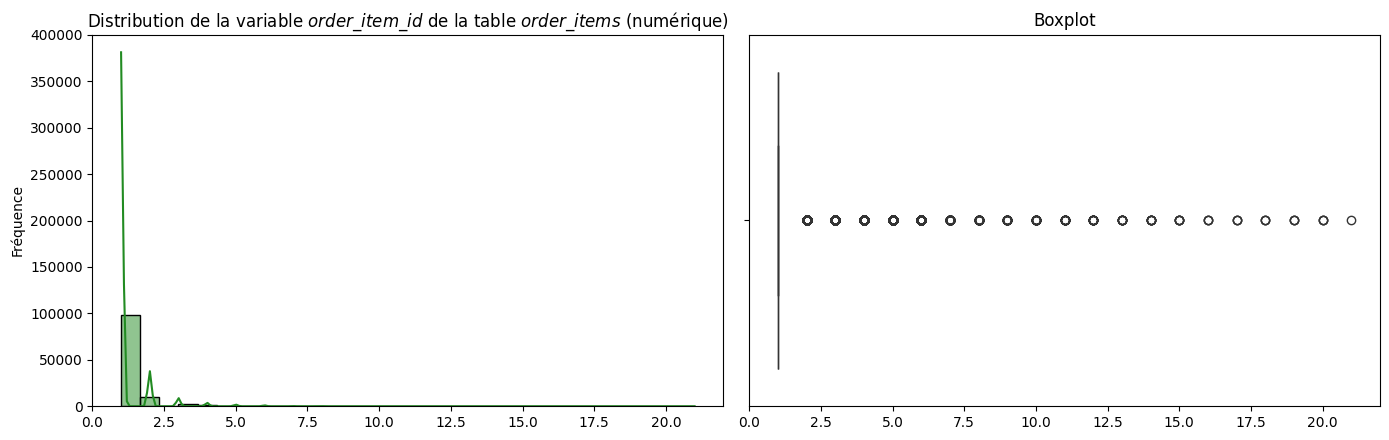

In [183]:
# Conversion des colonnes de date
cols_to_convert = ['shipping_limit_date']
order_items[cols_to_convert] = order_items[cols_to_convert].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Affichage du profil
profile_order_items = profile_dataframe(order_items, "order_items", primary_keys)
display(profile_order_items)

# Affichage de la distribution
plot_distributions(order_items, ["price", "freight_value", "order_item_id"], table_name="order_items")

## **ORDER_PAYMENTS**


=== Table : order_payments ===
Taille : 103886 lignes × 5 colonnes
Clé primaire : 'order_id', 'payment_sequential' → 0 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,order_id,b81ef226f3fe1789b1e8b2acac839d17,object,texte,99440,4.28,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,payment_sequential,1,int64,numérique,29,99.97,0.0,0.00,1.0,1.00,1.0,1.0000,29.00,1.09
2,payment_type,credit_card,object,texte,5,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,payment_installments,8,int64,numérique,24,NaN,0.0,0.00,0.0,1.00,1.0,4.0000,24.00,2.85
4,payment_value,99.33,float64,numérique,29077,NaN,0.0,0.01,0.0,56.79,100.0,171.8375,13664.08,154.10


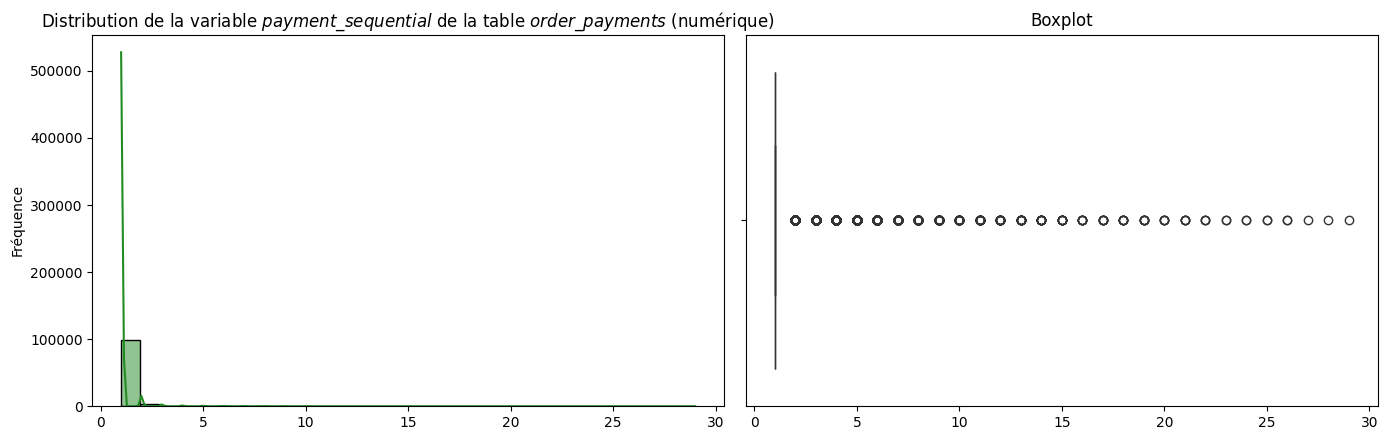

C:\Users\barre\AppData\Local\Temp\ipykernel_20520\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


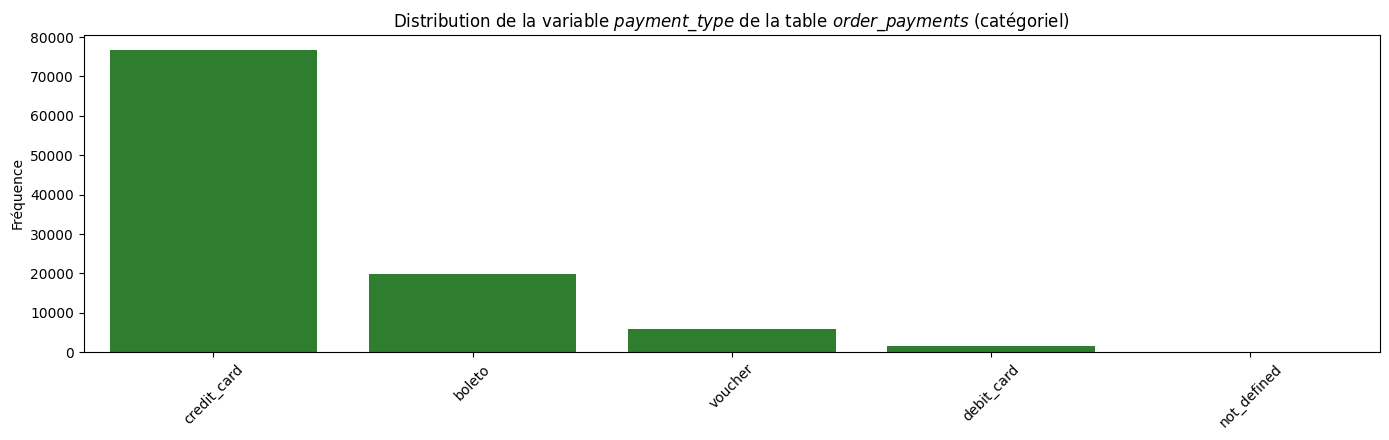

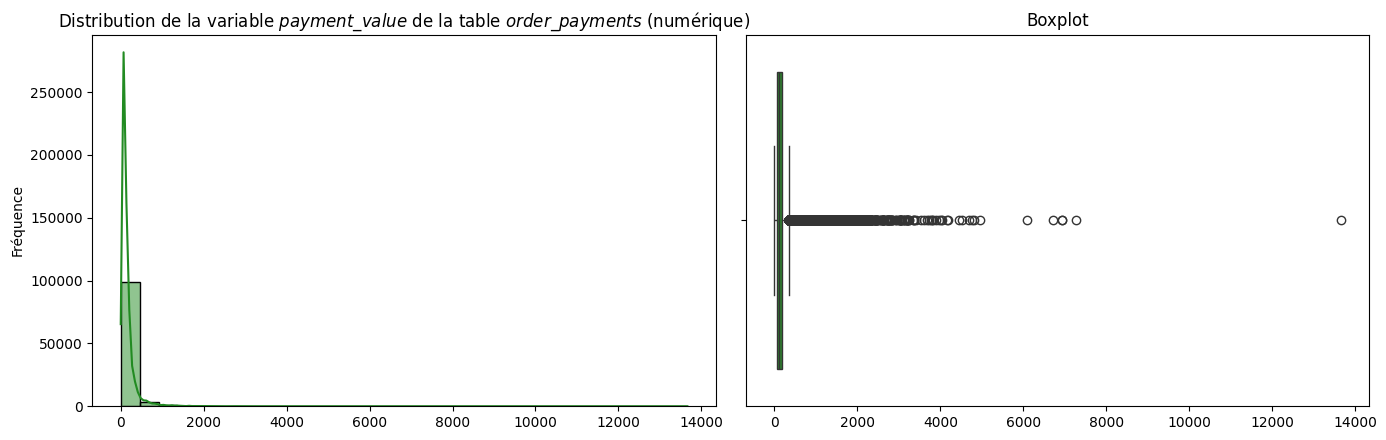

In [184]:
# Affichage du profil
profile_order_payments = profile_dataframe(order_payments, "order_payments", primary_keys)
display(profile_order_payments)

# Affichage de la distribution
plot_distributions(order_payments, ["payment_sequential", "payment_type", "payment_value"], table_name="order_payments")

## **ORDER_REVIEW**


=== Table : order_reviews ===
Taille : 99224 lignes × 7 colonnes
Clé primaire : 'review_id' → 1603 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,review_id,7bc2406110b926393aa56f80a40eba40,object,texte,98410,0.82,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,order_id,73fc7af87114b39712e6da79b0a377eb,object,texte,98673,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,review_score,4,int64,numérique,5,NaN,0.00,0.0,1,4.0,5.0,5.0,5,4.09
3,review_comment_title,NaN,object,texte,4528,NaN,88.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,review_comment_message,NaN,object,texte,36160,NaN,58.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,review_creation_date,2018-01-18 00:00:00,datetime64[ns],date,636,NaN,0.00,NaN,2016-10-02 00:00:00,2017-09-23 00:00:00,2018-02-02 00:00:00,2018-05-16 00:00:00,2018-08-31 00:00:00,NaN
6,review_answer_timestamp,2018-01-18 21:46:59,datetime64[ns],date,98248,NaN,0.00,NaN,2016-10-07 18:32:28,2017-09-27 01:53:27.249999872,2018-02-04 22:41:47.500000,2018-05-20 12:11:21.500000,2018-10-29 12:27:35,NaN


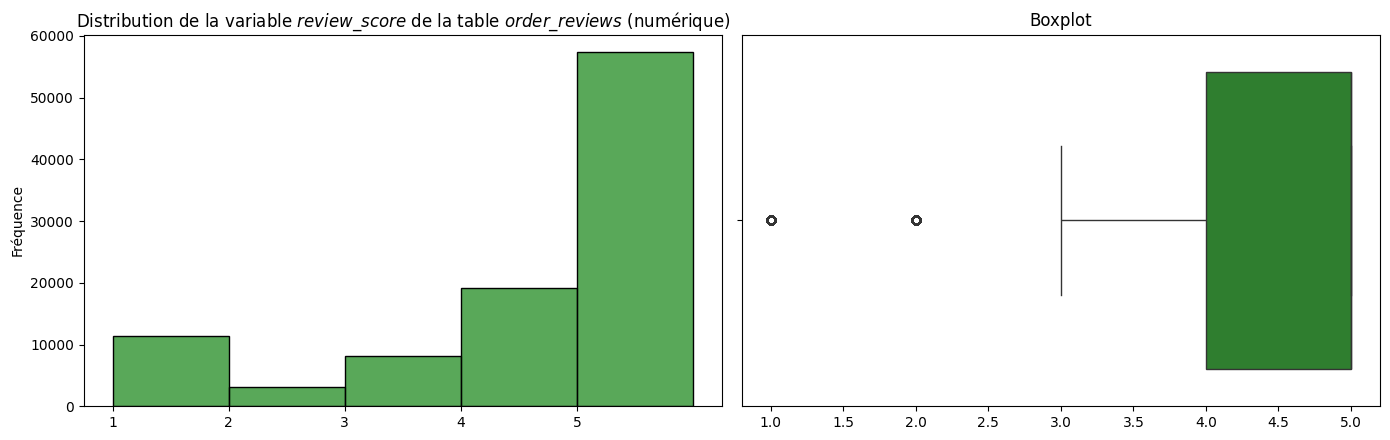

In [192]:
# Suppression des doublons sur review_id
# order_reviews = order_reviews.drop_duplicates(subset=['review_id'], keep='first')

# Conversion des colonnes de date
cols_to_convert = ['review_creation_date', 'review_answer_timestamp']
order_reviews[cols_to_convert] = order_reviews[cols_to_convert].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# Affichage du profil
profile_order_reviews = profile_dataframe(order_reviews, "order_reviews", primary_keys)
display(profile_order_reviews)

# Affichage de la distribution
plot_distributions(order_reviews, "review_score", table_name="order_reviews")


## **ORDERS**


=== Table : orders ===
Taille : 99441 lignes × 8 colonnes
Clé primaire : 'order_id' → 0 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,order_id,e481f51cbdc54678b7cc49136f2d6af7,object,texte,99441,0.0,0.00,NaN,NaT,NaT,NaT,NaT,NaT,NaN
1,customer_id,9ef432eb6251297304e76186b10a928d,object,texte,99441,NaN,0.00,NaN,NaT,NaT,NaT,NaT,NaT,NaN
2,order_status,delivered,object,texte,8,NaN,0.00,NaN,NaT,NaT,NaT,NaT,NaT,NaN
3,order_purchase_timestamp,2017-10-02 10:56:33,datetime64[ns],date,98875,NaN,0.00,NaN,2016-09-04 21:15:19,2017-09-12 14:46:19.000000000,2018-01-18 23:04:36.000,2018-05-04 15:42:16.000000000,2018-10-17 17:30:18,NaN
4,order_approved_at,2017-10-02 11:07:15,datetime64[ns],date,90734,NaN,0.16,NaN,2016-09-15 12:16:38,2017-09-12 23:24:16.000000000,2018-01-19 11:36:13.000,2018-05-04 20:35:10.000000000,2018-09-03 17:40:06,NaN
5,order_delivered_carrier_date,2017-10-04 19:55:00,datetime64[ns],date,81019,NaN,1.79,NaN,2016-10-08 10:34:01,2017-09-15 22:28:50.249999872,2018-01-24 16:10:58.000,2018-05-08 13:37:45.000000000,2018-09-11 19:48:28,NaN
6,order_delivered_customer_date,2017-10-10 21:25:13,datetime64[ns],date,95665,NaN,2.98,NaN,2016-10-11 13:46:32,2017-09-25 22:07:22.249999872,2018-02-02 19:28:10.500,2018-05-15 22:48:52.249999872,2018-10-17 13:22:46,NaN
7,order_estimated_delivery_date,2017-10-18 00:00:00,datetime64[ns],date,459,NaN,0.00,NaN,2016-09-30 00:00:00,2017-10-03 00:00:00.000000000,2018-02-15 00:00:00.000,2018-05-25 00:00:00.000000000,2018-11-12 00:00:00,NaN


C:\Users\barre\AppData\Local\Temp\ipykernel_20520\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


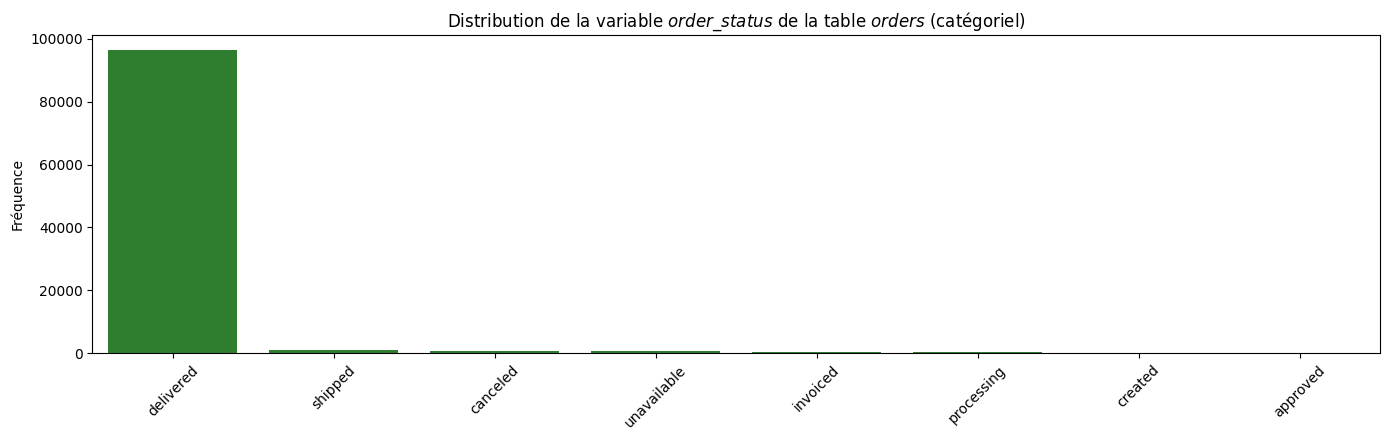

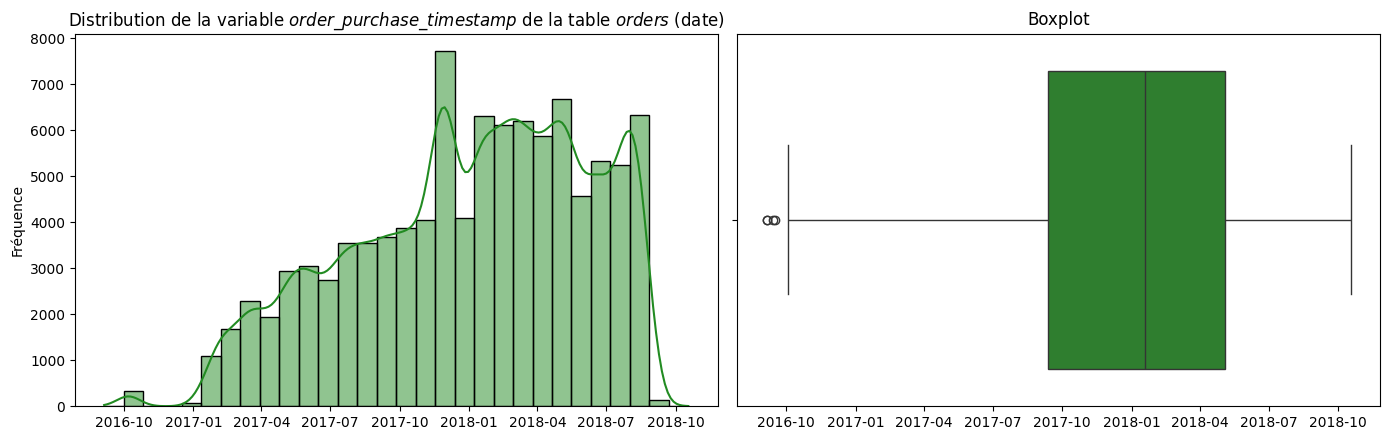

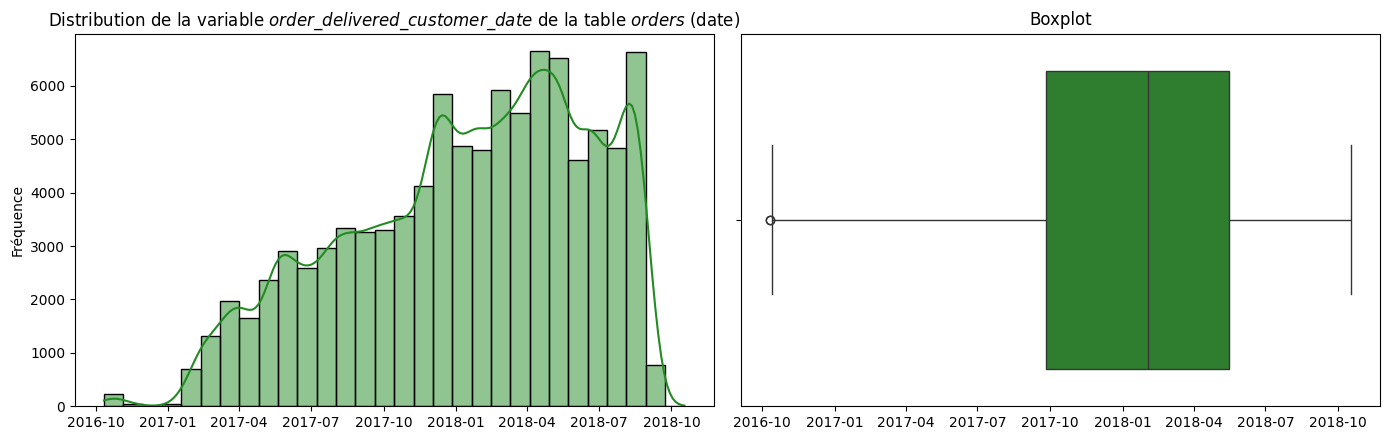

In [186]:
# Conversion des colonnes de date
cols_to_convert_orders = ['order_purchase_timestamp', 'order_approved_at', 
                          'order_delivered_carrier_date', 'order_delivered_customer_date', 
                          'order_estimated_delivery_date']
orders[cols_to_convert_orders] = orders[cols_to_convert_orders].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# Affichage du profil
profile_orders = profile_dataframe(orders, "orders", primary_keys)
display(profile_orders)

# Affichage de la distribution
plot_distributions(orders, ["order_status", "order_purchase_timestamp", "order_delivered_customer_date"], table_name="orders")

## **PRODUCTS**


=== Table : products ===
Taille : 32951 lignes × 9 colonnes
Clé primaire : 'product_id' → 0 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,product_id,1e9e8ef04dbcff4541ed26657ea517e5,object,texte,32951,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,product_category_name,perfumaria,object,texte,74,NaN,1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,product_name_lenght,40.0,float64,numérique,67,NaN,1.85,0.00,5.0,42.0,51.0,57.0,76.0,48.48
3,product_description_lenght,287.0,float64,numérique,2961,NaN,1.85,0.00,4.0,339.0,595.0,972.0,3992.0,771.50
4,product_photos_qty,1.0,float64,numérique,20,NaN,1.85,0.00,1.0,1.0,1.0,3.0,20.0,2.19
5,product_weight_g,225.0,float64,numérique,2205,NaN,0.01,0.01,0.0,300.0,700.0,1900.0,40425.0,2276.47
6,product_length_cm,16.0,float64,numérique,100,NaN,0.01,0.00,7.0,18.0,25.0,38.0,105.0,30.82
7,product_height_cm,10.0,float64,numérique,103,NaN,0.01,0.00,2.0,8.0,13.0,21.0,105.0,16.94
8,product_width_cm,14.0,float64,numérique,96,NaN,0.01,0.00,6.0,15.0,20.0,30.0,118.0,23.20


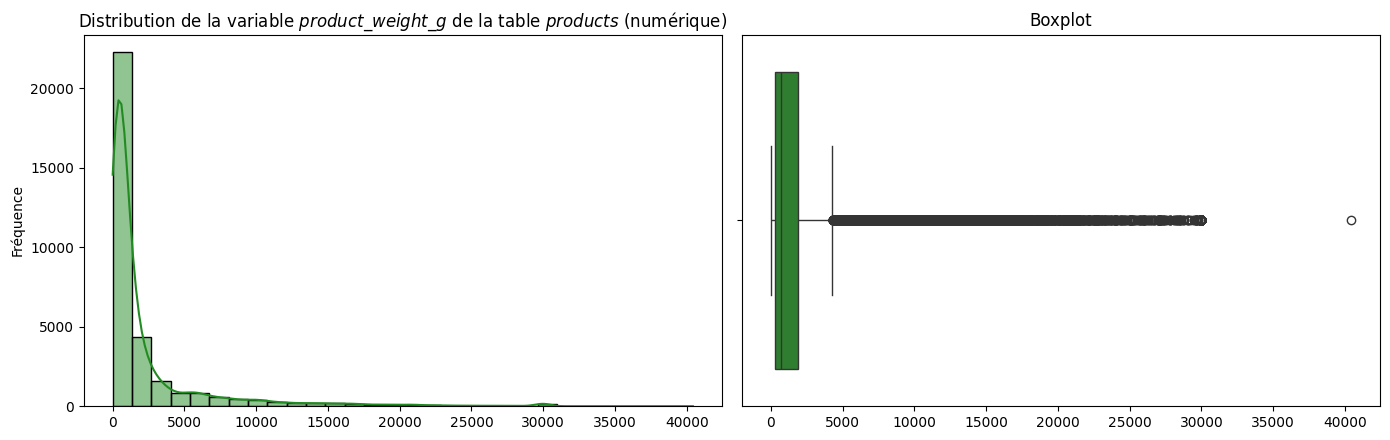

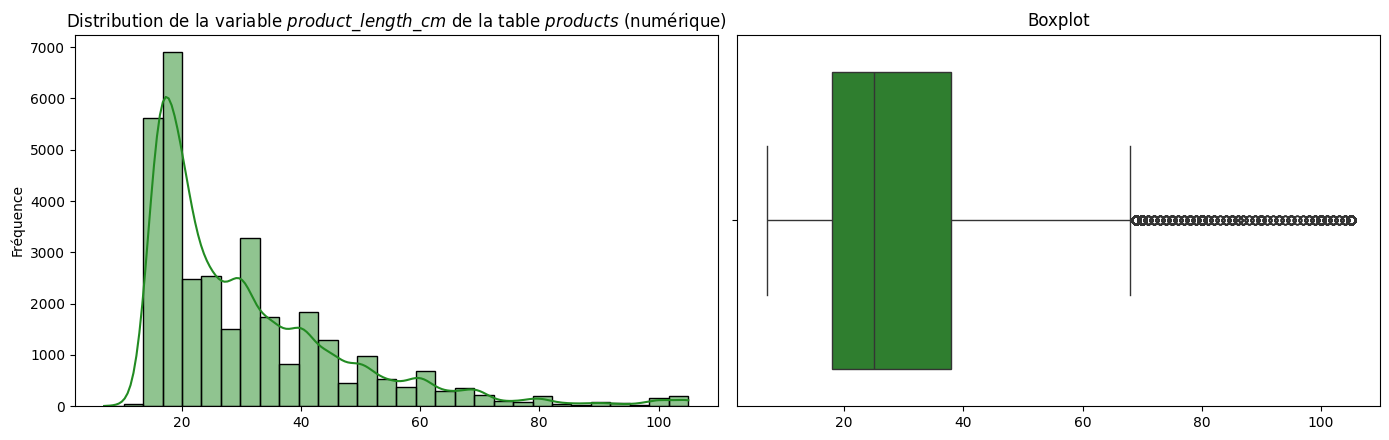

In [187]:
# Affichage du profil
profile_products = profile_dataframe(products, "products", primary_keys)
display(profile_products)

# Affichage de la distribution
plot_distributions(products, ["product_weight_g", "product_length_cm"], table_name="products")

In [188]:
value_frequencies(products, "product_category_name")

,valeur,fréquence,pourcentage
0,cama_mesa_banho,3029,9.19
1,esporte_lazer,2867,8.70
2,moveis_decoracao,2657,8.06
3,beleza_saude,2444,7.42
4,utilidades_domesticas,2335,7.09
...,...,...,...
69,fashion_roupa_infanto_juvenil,5,0.02
70,casa_conforto_2,5,0.02
71,pc_gamer,3,0.01
72,seguros_e_servicos,2,0.01


## **SELLERS**


=== Table : sellers ===
Taille : 3095 lignes × 4 colonnes
Clé primaire : 'seller_id' → 0 doublons

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,seller_id,3442f8959a84dea7ee197c632cb2df15,object,texte,3095,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,seller_zip_code_prefix,13023,int64,numérique,2246,NaN,0.0,0.0,1001.0,7093.5,14940.0,64552.5,99730.0,32291.06
2,seller_city,campinas,object,texte,611,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,seller_state,SP,object,texte,23,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\barre\AppData\Local\Temp\ipykernel_20520\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


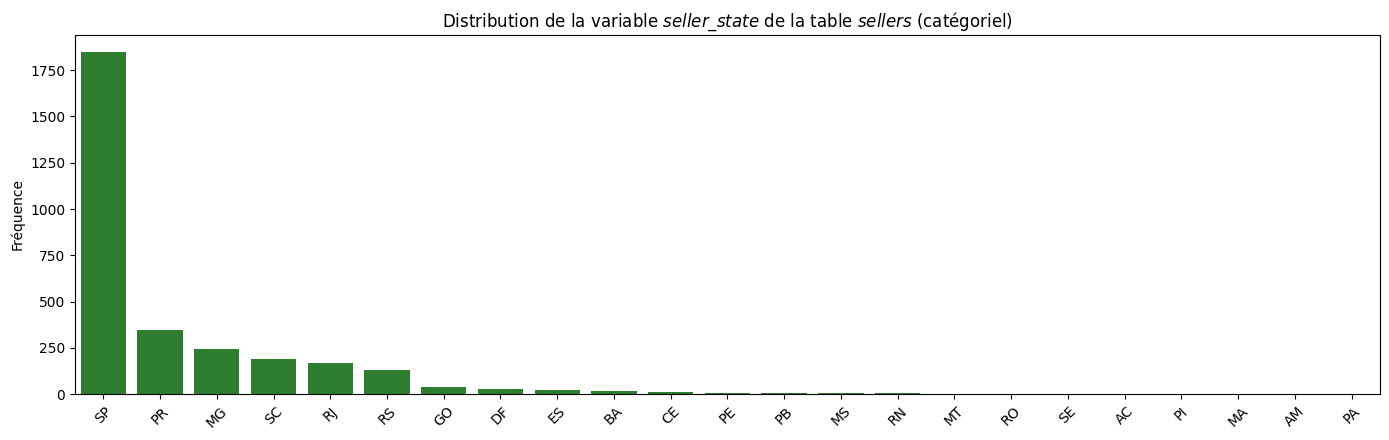

In [189]:
# Affichage du profil
profile_sellers = profile_dataframe(sellers, "sellers", primary_keys)
display(profile_sellers)

# Affichage de la distribution
plot_distributions(sellers, "seller_state", table_name="sellers")

## **FEATURE ENGINEERING**

In [233]:
# ============================================================
# 1. AGRÉGATION AU NIVEAU COMMANDE
# ============================================================

order_items_sum = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        order_total_value=('price', 'sum'),          # Montant total produits
        freight_total=('freight_value', 'sum'),      # Frais de port
        n_products=('product_id', 'nunique'),        # Nb produits distincts
        n_unique_sellers=('seller_id', 'nunique')    # Nb vendeurs distincts
    )
)

order_items_sum['order_total_value'] += order_items_sum['freight_total']


# ============================================================
# 2. ENRICHISSEMENT COMMANDES
# ============================================================

orders_enriched = (
    orders
    .merge(order_items_sum, on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
)

orders_enriched['order_purchase_timestamp'] = pd.to_datetime(
    orders_enriched['order_purchase_timestamp']
)


# ============================================================
# 3. FEATURES TEMPORELLES COMMANDE
# ============================================================

orders_enriched['order_weekend'] = (
    orders_enriched['order_purchase_timestamp'].dt.weekday >= 5
)

orders_enriched['order_month'] = orders_enriched['order_purchase_timestamp'].dt.month


# ============================================================
# 4. FEATURES PRODUITS / CATÉGORIES
# ============================================================

order_products = (
    order_items
    .merge(products, on='product_id', how='left')
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
)

order_products['product_volume'] = (
    order_products['product_length_cm'] *
    order_products['product_height_cm'] *
    order_products['product_width_cm']
)


# ============================================================
# 5. AGRÉGATION CATÉGORIES CLIENT
# ============================================================

# Nombre de catégories distinctes
n_unique_categories = (
    order_products
    .groupby('customer_unique_id')['product_category_name']
    .nunique()
    .reset_index(name='n_unique_categories')
)

# Catégorie dominante
category_dist = (
    order_products
    .groupby(['customer_unique_id', 'product_category_name'])
    .size()
    .reset_index(name='cnt')
)

max_category_pct = (
    category_dist
    .assign(
        pct=lambda x: x['cnt'] /
        x.groupby('customer_unique_id')['cnt'].transform('sum')
    )
    .groupby('customer_unique_id')['pct']
    .max()
    .reset_index(name='max_category_pct')
)

# Top N catégories binaires
TOP_N = 10
top_categories = (
    order_products['product_category_name']
    .value_counts()
    .head(TOP_N)
    .index
)

category_binary = (
    order_products
    .assign(flag=1)
    .pivot_table(
        index='customer_unique_id',
        columns='product_category_name',
        values='flag',
        aggfunc='max',
        fill_value=0
    )
    .reindex(columns=top_categories, fill_value=0)
    .add_prefix('cat_')
    .reset_index()
)

# Nombre de catégories parmi le top N
category_binary['n_categories_topN'] = (
    category_binary.filter(like='cat_').sum(axis=1)
)


# ============================================================
# 6. FEATURES PRODUITS MOYENS
# ============================================================

product_means = (
    order_products
    .groupby('customer_unique_id')
    .agg(
        avg_weight=('product_weight_g', 'mean'),
        avg_volume=('product_volume', 'mean'),
        avg_product_photos=('product_photos_qty', 'mean')
    )
    .reset_index()
)


# ============================================================
# 7. AGRÉGATION CLIENT – COMMANDES
# ============================================================

client_level = (
    orders_enriched
    .groupby('customer_unique_id', as_index=False)
    .agg(
        first_order_date=('order_purchase_timestamp', 'min'),
        last_order_date=('order_purchase_timestamp', 'max'),
        frequency_orders=('order_id', 'nunique'),
        total_products=('n_products', 'sum'),
        monetary_total=('order_total_value', 'sum'),
        monetary_avg=('order_total_value', 'mean'),
        max_order_value=('order_total_value', 'max'),
        min_order_value=('order_total_value', 'min'),
        max_products_per_order=('n_products', 'max'),
        n_unique_sellers=('n_unique_sellers', 'sum'),
        weekend_order_pct=('order_weekend', 'mean')
    )
)


# ============================================================
# 8. FEATURES TEMPORELLES CLIENT
# ============================================================

last_date = client_level['last_order_date'].max()

client_level['recency_days'] = (
    last_date - client_level['last_order_date']
).dt.days

client_level['days_since_first_order'] = (
    last_date - client_level['first_order_date']
).dt.days


# ============================================================
# 9. FEATURES REVIEWS
# ============================================================

client_reviews = (
    order_reviews
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
    .assign(positive=lambda x: x['review_score'] >= 4)
    .groupby('customer_unique_id')
    .agg(
        n_review_total=('review_id', 'nunique'),
        avg_review_score=('review_score', 'mean'),
        pct_positive_reviews=('positive', 'mean')
    )
    .reset_index()
)

client_level = client_level.merge(client_reviews, on='customer_unique_id', how='left')
client_level[['n_review_total', 'avg_review_score', 'pct_positive_reviews']] = (
    client_level[['n_review_total', 'avg_review_score', 'pct_positive_reviews']].fillna(0)
)

client_level['review_count_per_order'] = (
    client_level['n_review_total'] / client_level['frequency_orders']
)


# ============================================================
# 10. FEATURES PAIEMENT
# ============================================================

payments_enriched = (
    order_payments
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
)

payment_mode = (
    payments_enriched
    .groupby(['customer_unique_id', 'payment_type'])
    .size()
    .reset_index(name='cnt')
    .sort_values(['customer_unique_id', 'cnt'], ascending=False)
    .drop_duplicates('customer_unique_id')
    .pivot_table(
        index='customer_unique_id',
        columns='payment_type',
        values='cnt',
        fill_value=0
    )
    .reset_index()
    .add_prefix('payment_')
)


# ============================================================
# 11. FUSIONS FINALES
# ============================================================

client_level = (
    client_level
    .merge(n_unique_categories, on='customer_unique_id', how='left')
    .merge(max_category_pct, on='customer_unique_id', how='left')
    .merge(product_means, on='customer_unique_id', how='left')
    .merge(category_binary, on='customer_unique_id', how='left')
    .merge(payment_mode, left_on='customer_unique_id', right_on='payment_customer_unique_id', how='left')
)

client_level = client_level.fillna(0)


In [242]:
# ============================================================
# PROFIL + SÉLECTION AUTOMATIQUE DES VARIABLES À DISTRIBUER
# ============================================================

# Profil du dataframe
profile_client_level = profile_dataframe(
    client_level,
    table_name="client_level",
    primary_keys=primary_keys
)
display(profile_client_level)

# Sélection des variables pertinentes pour les distributions
distribution_cols = (
    client_level
    .select_dtypes(include=["int64", "float64"])
    .loc[:, lambda df: df.nunique() > 2]                 # enlève constantes / quasi constantes
    .loc[:, lambda df: df.isna().mean() < 0.3]            # enlève colonnes trop manquantes
    .columns
    .tolist()
)

# Exclure les variables binaires (0/1)
distribution_cols = [
    col for col in distribution_cols
    if not set(client_level[col].dropna().unique()).issubset({0, 1})
]

# Affichage des distributions
# plot_distributions(
#     client_level,
#     distribution_cols,
#     table_name="client_level"
# )



=== Table : client_level ===
Taille : 96096 lignes × 41 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,96096,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,first_order_date,2018-05-10 10:56:27,datetime64[ns],date,95837,NaN,0.0,NaN,2016-09-04 21:15:19,2017-09-11 19:52:06,2018-01-18 13:33:08,2018-05-04 10:38:45,2018-10-17 17:30:18,NaN
2,last_order_date,2018-05-10 10:56:27,datetime64[ns],date,95834,NaN,0.0,NaN,2016-09-04 21:15:19,2017-09-15 09:04:17.249999872,2018-01-21 19:39:16,2018-05-06 20:14:49.750000128,2018-10-17 17:30:18,NaN
3,frequency_orders,1,int64,numérique,9,NaN,0.0,0.00,1,1.0,1.0,1.0,17,1.03
4,total_products,1.0,float64,numérique,12,NaN,0.0,0.70,0.0,1.0,1.0,1.0,16.0,1.07
5,monetary_total,141.9,float64,numérique,31718,NaN,0.0,0.70,0.0,62.39,107.27,182.2375,13664.08,164.87
6,monetary_avg,141.9,float64,numérique,31873,NaN,0.0,0.70,0.0,61.73,105.22,176.3225,13664.08,159.91
7,max_order_value,141.9,float64,numérique,30725,NaN,0.0,0.70,0.0,61.8775,105.87,177.99,13664.08,161.41
8,min_order_value,141.9,float64,numérique,30350,NaN,0.0,0.70,0.0,60.5375,103.55,174.82,13664.08,158.47
9,max_products_per_order,1.0,float64,numérique,9,NaN,0.0,0.70,0.0,1.0,1.0,1.0,8.0,1.03


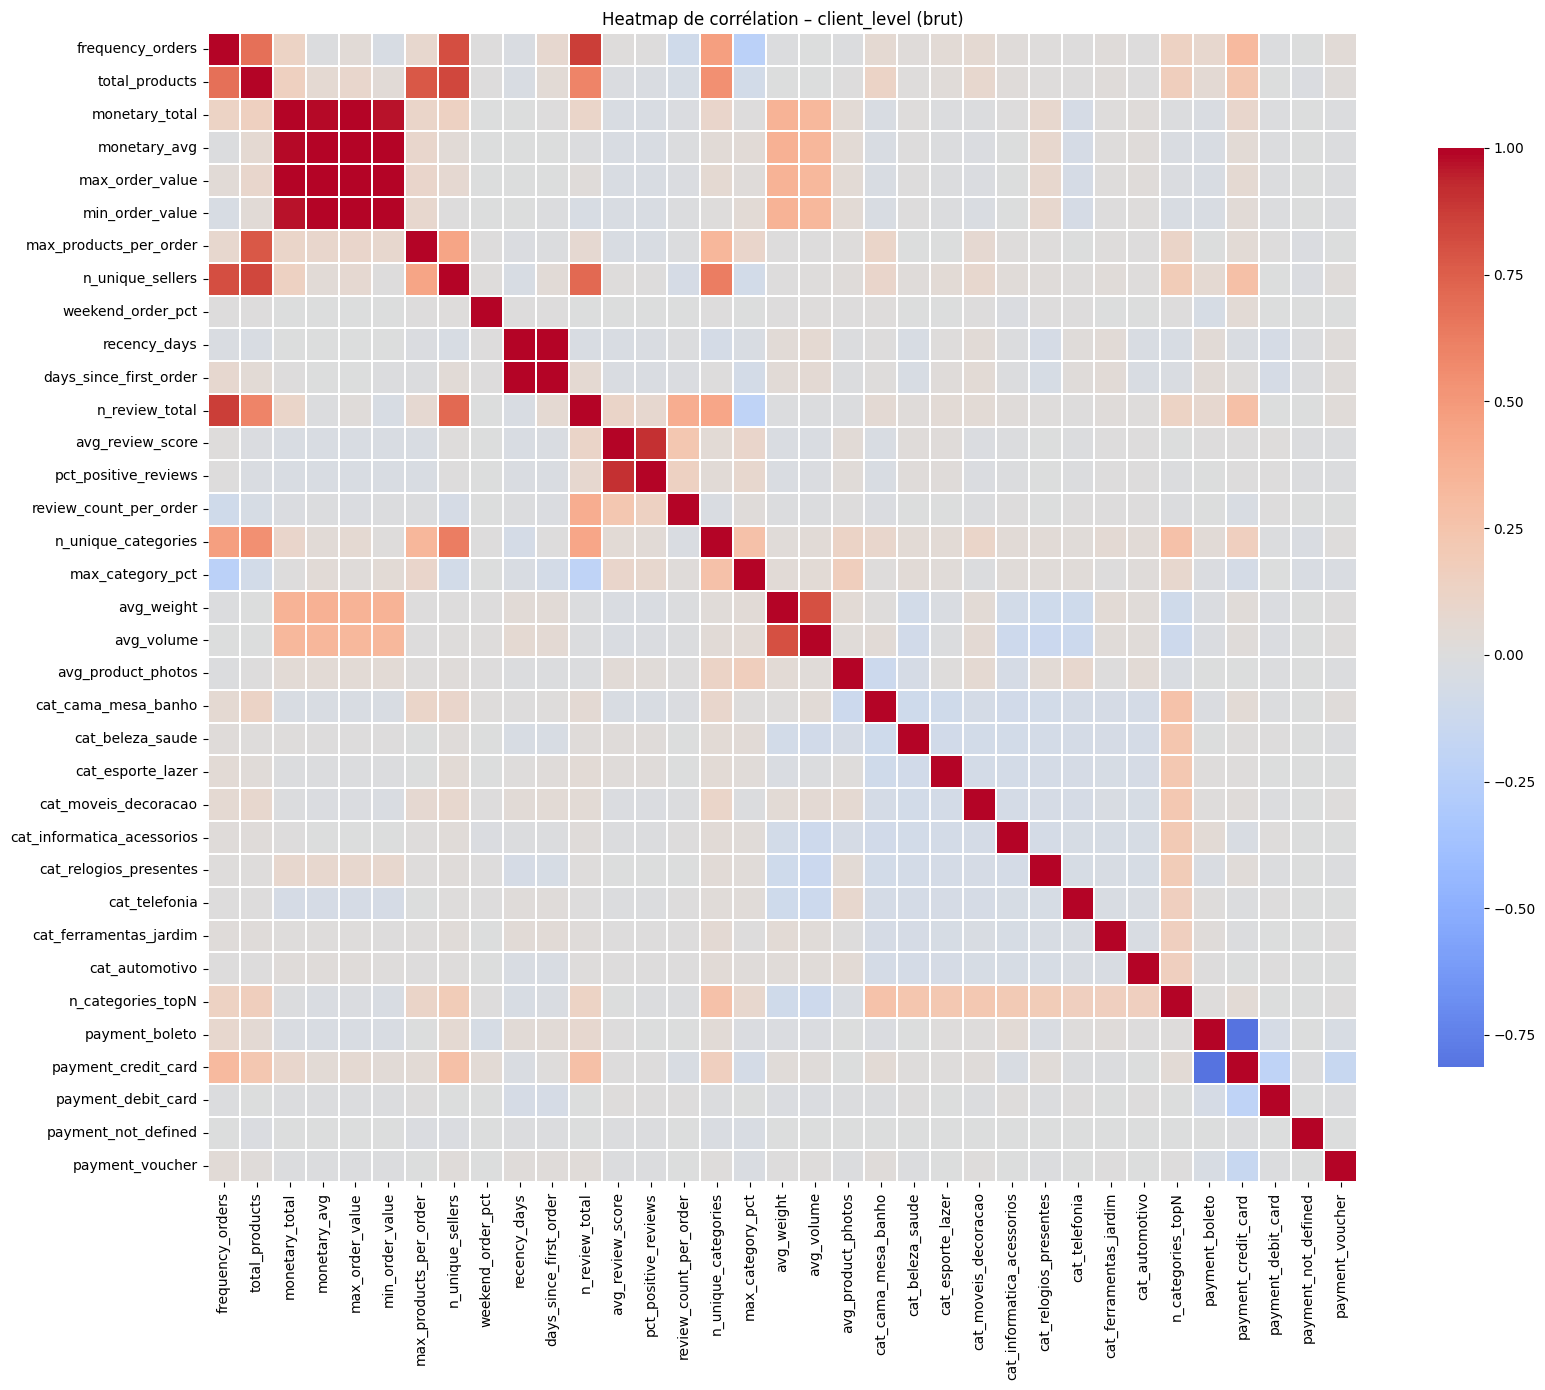

In [238]:
# 1. Sélection automatique des colonnes numériques
numeric_cols = client_level.select_dtypes(include=[np.number])

# 2. Suppression des colonnes identifiants évidentes si présentes
id_like_cols = [c for c in numeric_cols.columns if 'id' in c.lower()]
numeric_cols = numeric_cols.drop(columns=id_like_cols, errors='ignore')

# 3. Matrice de corrélation (NaN gérés automatiquement)
corr_matrix = numeric_cols.corr()

# 4. Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap de corrélation – client_level (brut)")
plt.tight_layout()
plt.show()


| Catégorie     | Variable                   | Statut recommandé    | Justification                                                 |
| ------------- | -------------------------- | -------------------- | ------------------------------------------------------------- |
| Identifiant   | customer_unique_id         | Garder (hors modèle) | Clé client, indispensable pour jointures mais à exclure du ML |
| Valeur client | monetary_total             | Garder               | Mesure globale de valeur, très discriminante                  |
| Valeur client | monetary_avg               | Supprimer            | Fortement corrélée à monetary_total                           |
| Valeur client | max_order_value            | Garder               | Capture les achats exceptionnels                              |
| Valeur client | min_order_value            | Supprimer            | Peu discriminante, redondante                                 |
| Fréquence     | frequency_orders           | Optionnel            | Faible variance (majorité = 1)                                |
| Produits      | total_products             | Supprimer            | Redondant avec fréquence                                      |
| Produits      | max_products_per_order     | Optionnel            | Faible variance                                               |
| Temporalité   | recency_days               | Garder               | Variable clé RFM                                              |
| Temporalité   | days_since_first_order     | Optionnel            | Corrélée à recency, utile pour cycle de vie                   |
| Engagement    | n_review_total             | Garder               | Indicateur d’engagement client                                |
| Engagement    | avg_review_score           | Optionnel            | Beaucoup de zéros (absence de review)                         |
| Engagement    | pct_positive_reviews       | Garder               | Plus robuste que la moyenne                                   |
| Engagement    | review_count_per_order     | Supprimer            | Faible variance                                               |
| Comportement  | weekend_order_pct          | Garder               | Habitude d’achat temporelle                                   |
| Diversité     | n_unique_categories        | Supprimer            | Très concentrée sur 1                                         |
| Diversité     | n_categories_topN          | Garder               | Bonne synthèse de diversité                                   |
| Préférences   | max_category_pct           | Garder               | Mesure de spécialisation                                      |
| Produits      | avg_weight                 | Garder               | Typologie produits achetés                                    |
| Produits      | avg_volume                 | Garder               | Complémentaire au poids                                       |
| Produits      | avg_product_photos         | Garder               | Proxy d’intérêt produit                                       |
| Catégories    | cat_* (one-hot)            | Optionnel            | Garder uniquement top 5–8                                     |
| Paiement      | payment_*                  | À transformer        | Préférer mode dominant ou % credit card                       |
| Paiement      | payment_customer_unique_id | Supprimer            | Colonne parasite                                              |
| Qualité       | has_review (à créer)       | Recommandé           | Distingue 0 review vs mauvaise note                           |


In [245]:
# ==============================
# 1. Copie de travail
# ==============================
# Crée une copie pour travailler sans modifier l'original
df = client_level.copy()

# ==============================
# 2. Gestion des reviews
# ==============================
# Création d'une variable binaire : 1 si le client a au moins une review, 0 sinon
df['has_review'] = (df['n_review_total'] > 0).astype(int)

# Pour les colonnes de review, mettre NaN si pas de review pour éviter de biaiser les stats
for col in ['pct_positive_reviews', 'avg_review_score']:
    if col in df.columns:
        df.loc[df['has_review'] == 0, col] = np.nan

# ==============================
# 3. Paiement : proportion carte de crédit
# ==============================
payment_cols = [c for c in df.columns if c.startswith('payment_')]

if payment_cols and 'payment_credit_card' in df.columns:
    # Conversion en numérique pour éviter erreurs (non numériques → 0)
    df[payment_cols] = df[payment_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

    # Proportion de paiements par carte de crédit
    df['pct_credit_card'] = df['payment_credit_card'] / df[payment_cols].sum(axis=1)

# Suppression des colonnes de paiement originales et de la clé parasite
df = df.drop(columns=payment_cols + ['payment_customer_unique_id'], errors='ignore')

# ==============================
# 4. Catégories produits : garder top N
# ==============================
cat_cols = [c for c in df.columns if c.startswith('cat_')]
TOP_N = 8

if cat_cols:
    # Fréquence moyenne d'achat par catégorie
    cat_freq = df[cat_cols].mean().sort_values(ascending=False)

    # Sélection des TOP N catégories les plus représentatives
    top_cat_cols = cat_freq.head(TOP_N).index.tolist()

    # Suppression des catégories moins fréquentes
    df = df.drop(columns=[c for c in cat_cols if c not in top_cat_cols], errors='ignore')

# ==============================
# 5. Colonnes finales sélectionnées pour clustering
# ==============================
final_features = [
    # RFM / valeur
    'recency_days', 'monetary_total', 'max_order_value',

    # Engagement / avis
    'n_review_total', 'pct_positive_reviews',

    # Comportement client
    'weekend_order_pct', 'avg_product_photos',

    # Diversité / préférences produits
    'n_categories_topN', 'max_category_pct', 'avg_weight', 'avg_volume',

    # Paiement
    'pct_credit_card',

    # Indicateur review
    'has_review'
] + top_cat_cols  # Ajouter dynamiquement les catégories conservées

# Filtrage final pour garder uniquement les colonnes existantes
client_level_V2 = df[[c for c in final_features if c in df.columns]].copy()

# ==============================
# 6. Vérifications finales
# ==============================
print("Shape df client_level_V2 :", client_level_V2.shape)
profile_df = profile_dataframe(client_level_V2, "client_level_V2", primary_keys)
display(profile_df)

Shape df client_level_V2 : (96096, 21)

=== Table : client_level_V2 ===
Taille : 96096 lignes × 21 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,recency_days,160.0,int64,numérique,630,NaN,0.00,0.00,0.0,163.0000,268.00,397.0000,772.00,287.74
1,monetary_total,141.9,float64,numérique,31718,NaN,0.00,0.70,0.0,62.3900,107.27,182.2375,13664.08,164.87
2,max_order_value,141.9,float64,numérique,30725,NaN,0.00,0.70,0.0,61.8775,105.87,177.9900,13664.08,161.41
3,n_review_total,1.0,float64,numérique,10,NaN,0.00,0.75,0.0,1.0000,1.00,1.0000,17.00,1.02
4,pct_positive_reviews,1.0,float64,numérique,15,NaN,0.75,22.43,0.0,1.0000,1.00,1.0000,1.00,0.77
5,weekend_order_pct,0.0,float64,numérique,11,NaN,0.00,76.66,0.0,0.0000,0.00,0.0000,1.00,0.23
6,avg_product_photos,1.0,float64,numérique,101,NaN,0.00,2.07,0.0,1.0000,1.50,3.0000,20.00,2.21
7,n_categories_topN,1.0,float64,numérique,5,NaN,0.00,37.36,0.0,0.0000,1.00,1.0000,4.00,0.64
8,max_category_pct,1.0,float64,numérique,27,NaN,0.00,2.07,0.0,1.0000,1.00,1.0000,1.00,0.97
9,avg_weight,1500.0,float64,numérique,3270,NaN,0.00,0.72,0.0,300.0000,700.00,1813.0000,40425.00,2092.04


# **SEGMENTATION RFM**

In [247]:
def rfm_segmentation(df, recency_col='recency_days', frequency_col='frequency_orders', monetary_col='monetary_total',
                     recency_thresholds=(30, 60, 90, 180, 365), frequency_thresholds=(5, 3, 1, 1), monetary_threshold=500):
    """
    Segmente les clients en fonction des règles RFM.
    
    Paramètres :
    - df : DataFrame contenant les colonnes de recency, frequency et monetary
    - recency_col : nom de la colonne pour la récence (jours depuis la dernière commande)
    - frequency_col : nom de la colonne pour la fréquence (nombre de commandes)
    - monetary_col : nom de la colonne pour le montant total dépensé
    - recency_thresholds : tuple des seuils pour recency (ordre : champions, loyal, potential loyal, to reactivate, lost)
    - frequency_thresholds : tuple des seuils pour frequency (ordre : champions, loyal, potential loyal, to reactivate)
    - monetary_threshold : seuil pour monetary pour le segment "champions"
    
    Retourne :
    - df avec une nouvelle colonne 'rfm_segment'
    """
    
    def assign_segment(row):
        # Champions
        if row[recency_col] <= recency_thresholds[0] and row[frequency_col] >= frequency_thresholds[0] and row[monetary_col] >= monetary_threshold:
            return "champions"
        # Loyal
        elif row[recency_col] <= recency_thresholds[1] and row[frequency_col] >= frequency_thresholds[1]:
            return "loyal"
        # Potential loyal
        elif row[recency_col] <= recency_thresholds[2] and row[frequency_col] >= frequency_thresholds[2]:
            return "potential loyal"
        # To reactivate
        elif row[recency_col] > recency_thresholds[3] and row[frequency_col] >= frequency_thresholds[3]:
            return "to reactivate"
        # Lost
        elif row[recency_col] > recency_thresholds[4]:
            return "lost"
        # At risk
        else:
            return "at risk"
    
    df = df.copy()
    df['rfm_segment'] = df.apply(assign_segment, axis=1)
    return df

In [248]:
client_level = rfm_segmentation(
    client_level,
    recency_col='recency_days',
    frequency_col='frequency_orders',
    monetary_col='monetary_total',
    recency_thresholds=(30, 90, 180, 365, np.inf),
    frequency_thresholds=(2, 1, 1, 0),
    monetary_threshold=150
)


--- Pourcentage par segment RFM ---
 rfm_segment
at risk            41.37
to reactivate      29.51
potential loyal    19.06
loyal              10.05
champions           0.00
Name: proportion, dtype: float64


C:\Users\barre\AppData\Local\Temp\ipykernel_20520\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


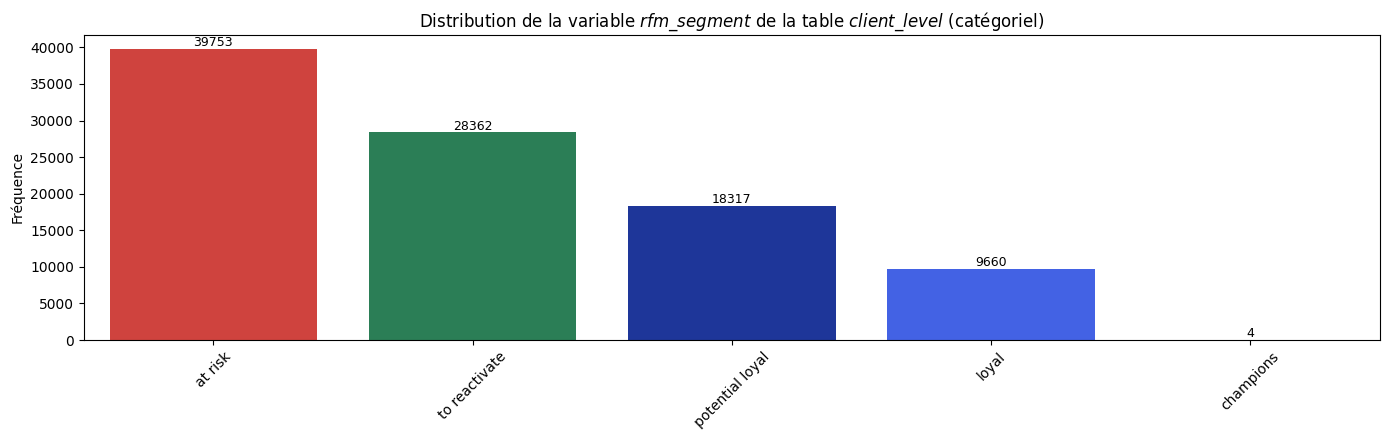

In [249]:
color_segment = {
    "loyal": "#2851FF",
    "potential loyal": "#092AAE",
    "champions": "#15C574",
    "to reactivate": "#1D8C56",
    "lost": "#910909",
    "at risk": "#E72C26"
}
pct_rfm_segment = client_level['rfm_segment'].value_counts(normalize=True) * 100
print("\n--- Pourcentage par segment RFM ---\n", pct_rfm_segment.round(2))
plot_distributions(client_level, ["rfm_segment"], table_name="client_level", show_values=True, color_dict=color_segment)

# **K-MEANS**

In [252]:
# ==============================
# 1. Copie de travail
# ==============================
df_cluster = client_level_V2.copy()

# ==============================
# 2. Identifier variables continues et binaires
# ==============================
binary_cols = [c for c in df_cluster.columns if set(df_cluster[c].dropna().unique()).issubset({0,1})]
continuous_cols = [c for c in df_cluster.columns if c not in binary_cols]

# ==============================
# 3. Remplacer NaN par 0 pour les binaires, et par la moyenne pour continues
# ==============================
df_cluster[binary_cols] = df_cluster[binary_cols].fillna(0)
df_cluster[continuous_cols] = df_cluster[continuous_cols].fillna(df_cluster[continuous_cols].mean())

# ==============================
# 4. Normalisation des variables continues
# ==============================
scaler = StandardScaler()
df_cluster[continuous_cols] = scaler.fit_transform(df_cluster[continuous_cols])

print("Shape df_cluster :", df_cluster.shape)
print("Aperçu :")
display(df_cluster.head())

Shape df_cluster : (96096, 21)
Aperçu :


,recency_days,monetary_total,max_order_value,n_review_total,pct_positive_reviews,weekend_order_pct,avg_product_photos,n_categories_topN,max_category_pct,avg_weight,...,pct_credit_card,has_review,cat_cama_mesa_banho,cat_beleza_saude,cat_esporte_lazer,cat_informatica_acessorios,cat_moveis_decoracao,cat_utilidades_domesticas,cat_relogios_presentes,cat_telefonia
0,-0.832621,-0.100783,-0.087665,-0.107988,0.550478,-0.548806,-0.691720,0.728211,0.198986,-0.158599,...,1.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.813067,-0.604035,-0.603134,-0.107988,0.550478,-0.548806,-0.691720,0.728211,0.198986,-0.459972,...,1.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.937662,-0.345060,-0.337872,-0.107988,-1.848411,-0.548806,0.453075,-1.269853,0.198986,-0.158599,...,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.529706,-0.531954,-0.529303,-0.107988,0.550478,-0.548806,1.597869,0.728211,0.198986,-0.520246,...,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.314602,0.140468,0.159443,-0.107988,0.550478,-0.548806,0.453075,0.728211,0.198986,1.060285,...,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [253]:
# CLUSTERING AVEC K-MEANS

# --- Paramètres initiaux ---
n_clusters_init = 4  # test initial
random_state = 42

# --- Initialisation et fit ---
kmeans_init = KMeans(n_clusters=n_clusters_init, random_state=random_state)
cluster_labels_init = kmeans_init.fit_predict(df_cluster)

# --- Ajout des labels au df pour analyse ---
df_cluster['cluster_init'] = cluster_labels_init

# --- Vérification ---
print("Distribution des clusters initiaux :")
print(df_cluster['cluster_init'].value_counts())

Distribution des clusters initiaux :
cluster_init
3    44765
1    25012
0    20539
2     5780
Name: count, dtype: int64


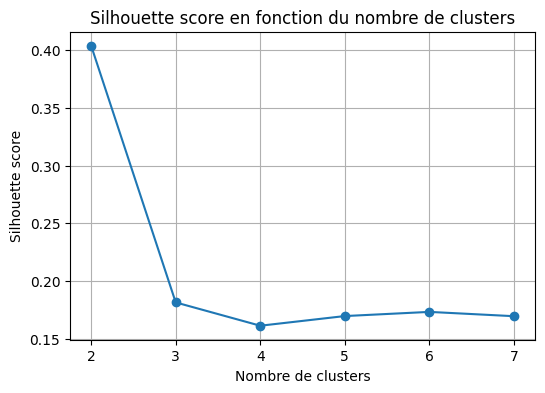

Nombre optimal de clusters selon silhouette : 2


In [254]:
# CHOIX DU NOMBRE OPTIMAL DE CLUSTERS

range_n_clusters = range(2, 8)
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(df_cluster.drop(columns=['cluster_init']))
    score = silhouette_score(df_cluster.drop(columns=['cluster_init']), labels)
    silhouette_scores.append(score)

# --- Affichage de la courbe ---
plt.figure(figsize=(6,4))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette score en fonction du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# --- Meilleur nombre de clusters selon silhouette ---
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
print("Nombre optimal de clusters selon silhouette :", best_k)


In [255]:
# ÉVALUATION DU CLUSTERING FINAL 

# --- Fit KMeans final ---
kmeans_final = KMeans(n_clusters=best_k, random_state=random_state)
df_cluster['cluster'] = kmeans_final.fit_predict(df_cluster.drop(columns=['cluster_init']))

# --- Vérifications quantitatives ---
inertia = kmeans_final.inertia_
sil_score = silhouette_score(df_cluster.drop(columns=['cluster_init', 'cluster']), df_cluster['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")
print("\nDistribution des clusters :")
print(df_cluster['cluster'].value_counts())


Inertia (somme des distances au centre) : 976065.72
Silhouette score : 0.404

Distribution des clusters :
cluster
0    88197
1     7899
Name: count, dtype: int64


recency_days        monetary_total        max_order_value         \
                mean median           mean median            mean median   
cluster                                                                    
0              -0.00  -0.13          -0.16  -0.29           -0.16  -0.29   
1               0.06  -0.10           1.82   0.98            1.83   0.98   

        n_review_total        pct_positive_reviews         ...  \
                  mean median                 mean median  ...   
cluster                                                    ...   
0                -0.00  -0.11                 0.01   0.55  ...   
1                 0.02  -0.11                -0.12   0.55  ...   

        cat_moveis_decoracao        cat_utilidades_domesticas         \
                        mean median                      mean median   
cluster                                                                
0                       0.07    0.0                      0.06    0.0   
1                       0.07    0.0                      0.10    0.0   

        cat_relogios_presentes        cat_telefonia        cluster_init         
                          mean median          mean median         mean median  
cluster                                                                         
0                         0.06    0.0          0.05    0.0         1.77    1.0  
1                         0.03    0.0          0.01    0.0         1.86    2.0  

[2 rows x 44 columns]

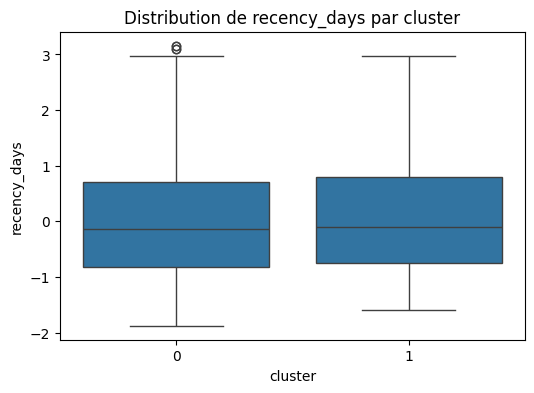

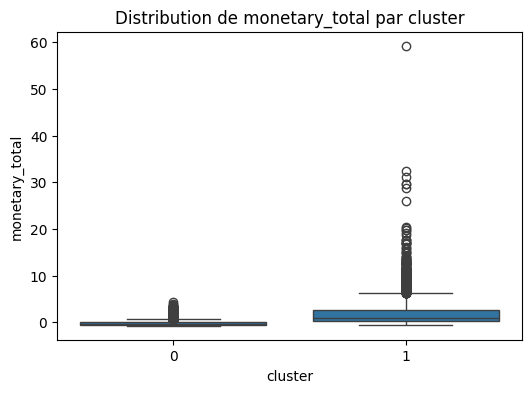

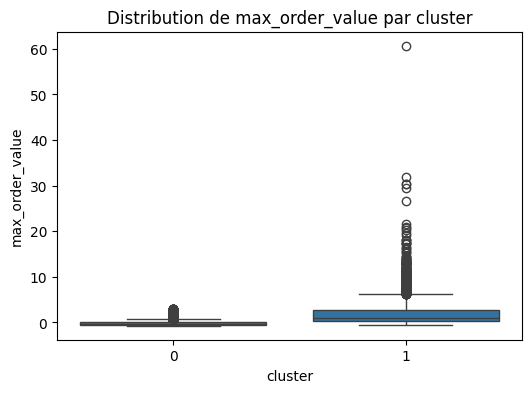

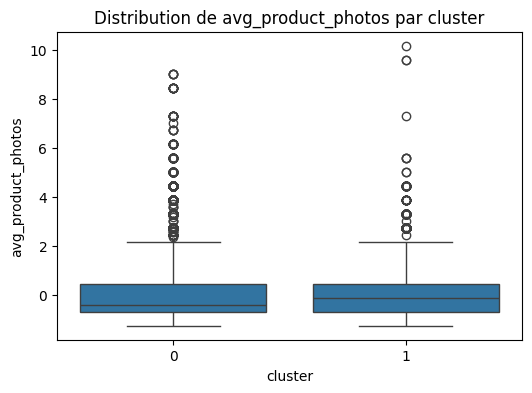

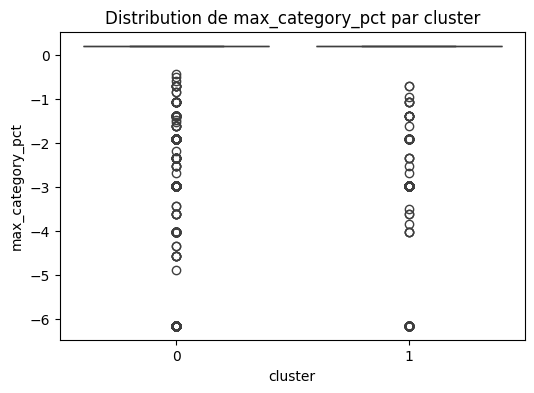

In [256]:
# INTERPRÉTATION DES CLUSTERS

# --- Moyenne et médiane par cluster ---
cluster_summary = df_cluster.groupby('cluster').agg(['mean', 'median']).round(2)
display(cluster_summary)

# --- Visualisation simplifiée de quelques features clés ---
features_to_plot = ['recency_days', 'monetary_total', 'max_order_value', 'avg_product_photos', 'max_category_pct']

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=feature, data=df_cluster)
    plt.title(f"Distribution de {feature} par cluster")
    plt.show()
